f:\Research\Project\Final\infant-growth-monitoring-system\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


🚀 Training will save model to: facial_pain_model.keras
--- Train Data ---
label
pain       250
no_pain     94
Name: count, dtype: int64
--- Val Data ---
label
pain       48
no_pain    20
Name: count, dtype: int64
--- Test Data ---
label
pain       70
no_pain    21
Name: count, dtype: int64
Found 344 validated image filenames belonging to 2 classes.
Found 68 validated image filenames belonging to 2 classes.
Found 91 validated image filenames belonging to 2 classes.
Class indices: {'no_pain': 0, 'pain': 1}

--- Starting Phase 1: Training the Head ---
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6648 - loss: 0.6442
Epoch 1: val_accuracy improved from None to 0.73529, saving model to facial_pain_model.keras

Epoch 1: finished saving model to facial_pain_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6773 - loss: 0.6733 - val_accuracy: 0.7353 - val_loss: 0.5854 - learning_rate: 1.0000e-04
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.6

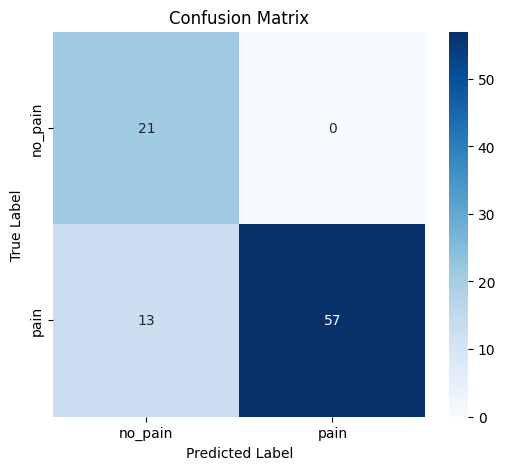

✅ Training Complete. Model saved as: facial_pain_model.keras


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# Replace with the actual path to your 'splitted' directory
DATA_DIR = '../data/raw/img/splitted'  
IMG_SIZE = (224, 224)  # Standard input size for MobileNetV2
BATCH_SIZE = 32
EPOCHS_HEAD = 10      # Epochs for initial training of the new head
EPOCHS_FINE = 15      # Epochs for fine-tuning

# UPDATE: Changed extension to .keras for modern format
MODEL_SAVE_PATH = 'facial_pain_model.keras'

print(f"🚀 Training will save model to: {MODEL_SAVE_PATH}")

# Function to create a DataFrame and map labels
def create_dataframe(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    filepaths = []
    labels = []
    
    # Iterate through subfolders (0, 0.5, 1, etc.)
    if not os.path.exists(split_dir):
        print(f"⚠️ Warning: Directory not found: {split_dir}")
        return pd.DataFrame(columns=['filepath', 'label'])

    for label_dir in os.listdir(split_dir):
        label_path = os.path.join(split_dir, label_dir)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepaths.append(os.path.join(label_path, file))
                    # --- Binary Mapping Logic ---
                    # Folder '0' is 'no_pain', everything else is 'pain'
                    if label_dir == '0':
                        labels.append('no_pain')
                    else:
                        labels.append('pain')
    
    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    # Shuffle the DataFrame
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"--- {split.capitalize()} Data ---")
    print(df['label'].value_counts())
    return df

# --- 1. Data Preparation ---
train_df = create_dataframe(DATA_DIR, 'train')
val_df = create_dataframe(DATA_DIR, 'val')
test_df = create_dataframe(DATA_DIR, 'test')

# --- 2. Data Generators with Augmentation ---
# Training generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test generators (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create the generators from the DataFrames
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Class indices: {train_generator.class_indices}")

# --- 3. Model Building (Transfer Learning) ---
# Load pre-trained MobileNetV2 without its top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))

# Freeze the base model initially
base_model.trainable = False

# Create a new head for binary classification
inputs = Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # Dropout to prevent overfitting
# Single output node with sigmoid activation for binary classification
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks for training
callbacks = [
    # Keras automatically detects .keras extension here
    ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# --- 4. Phase 1 Training (Train Only the New Head) ---
print("\n--- Starting Phase 1: Training the Head ---")
history_head = model.fit(
    train_generator,
    epochs=EPOCHS_HEAD,
    validation_data=val_generator,
    callbacks=callbacks
)

# --- 5. Phase 2 Fine-Tuning (Unfreeze and Train Base Model) ---
print("\n--- Starting Phase 2: Fine-Tuning ---")
# Unfreeze the base model
base_model.trainable = True

# Fine-tune only the top layers (e.g., from layer 100 onwards)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Re-compile with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Continue training
history_fine = model.fit(
    train_generator,
    initial_epoch=history_head.epoch[-1] + 1,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    validation_data=val_generator,
    callbacks=callbacks
)

# --- 6. Evaluation on Test Set ---
print("\n--- Final Evaluation on Test Set ---")
# Load the best model saved by the checkpoint
# Note: loading .keras usually requires less specific arguments
model.load_weights(MODEL_SAVE_PATH)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"✅ Training Complete. Model saved as: {MODEL_SAVE_PATH}")